Dataset Shape: (100000, 54)

First 5 rows:
   person_id  age     sex   region urban_rural  income     education  \
0      75722   52  Female    North    Suburban   22700     Doctorate   
1      80185   79  Female    North       Urban   12800         No HS   
2      19865   68    Male    North       Rural   40700            HS   
3      76700   15    Male    North    Suburban   15600  Some College   
4      92992   53    Male  Central    Suburban   89600     Doctorate   

  marital_status employment_status  household_size  ...  liver_disease  \
0        Married           Retired               3  ...              0   
1        Married          Employed               3  ...              0   
2        Married           Retired               5  ...              0   
3        Married     Self-employed               5  ...              0   
4        Married     Self-employed               2  ...              0   

   arthritis mental_health proc_imaging_count  proc_surgery_count  \
0         

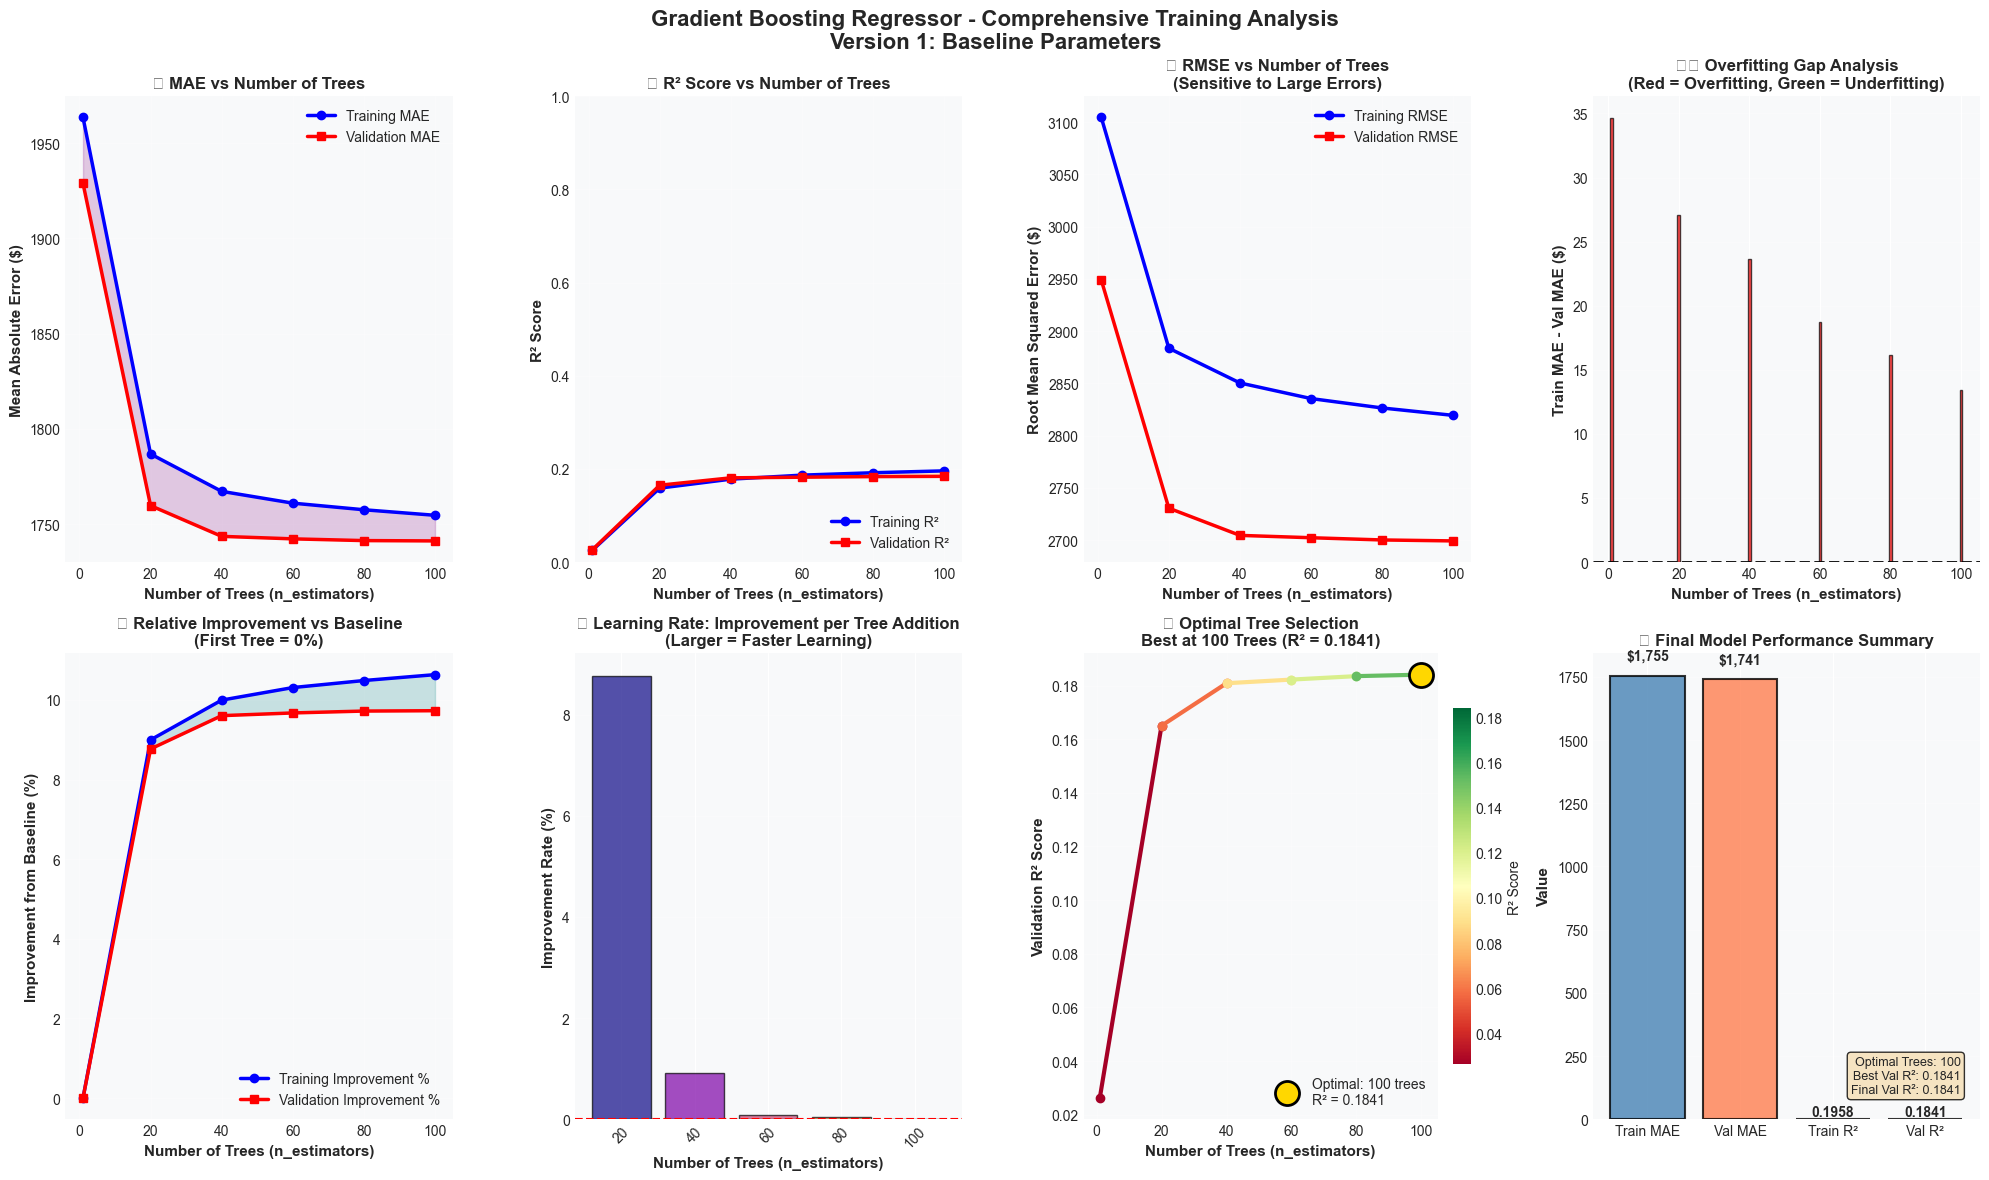


TRAINING SUMMARY STATISTICS

📈 Optimal Number of Trees: 100
   Best Validation R² Score: 0.1841
   Best Validation MAE: $1,741.15

🏁 Final Model Performance (100 trees):
   Training MAE: $1,754.60
   Validation MAE: $1,741.15
   Training R²: 0.1958
   Validation R²: 0.1841

⚠️ Overfitting Assessment:
   Gap: $13.45 - ✅ Good generalization

📊 Learning Progress:
   MAE Reduction: $208.83 (Training)
   MAE Reduction: $187.67 (Validation)
   R² Improvement: 0.1708 (Training)
   R² Improvement: 0.1579 (Validation)

GENERATING PERFORMANCE HEATMAP


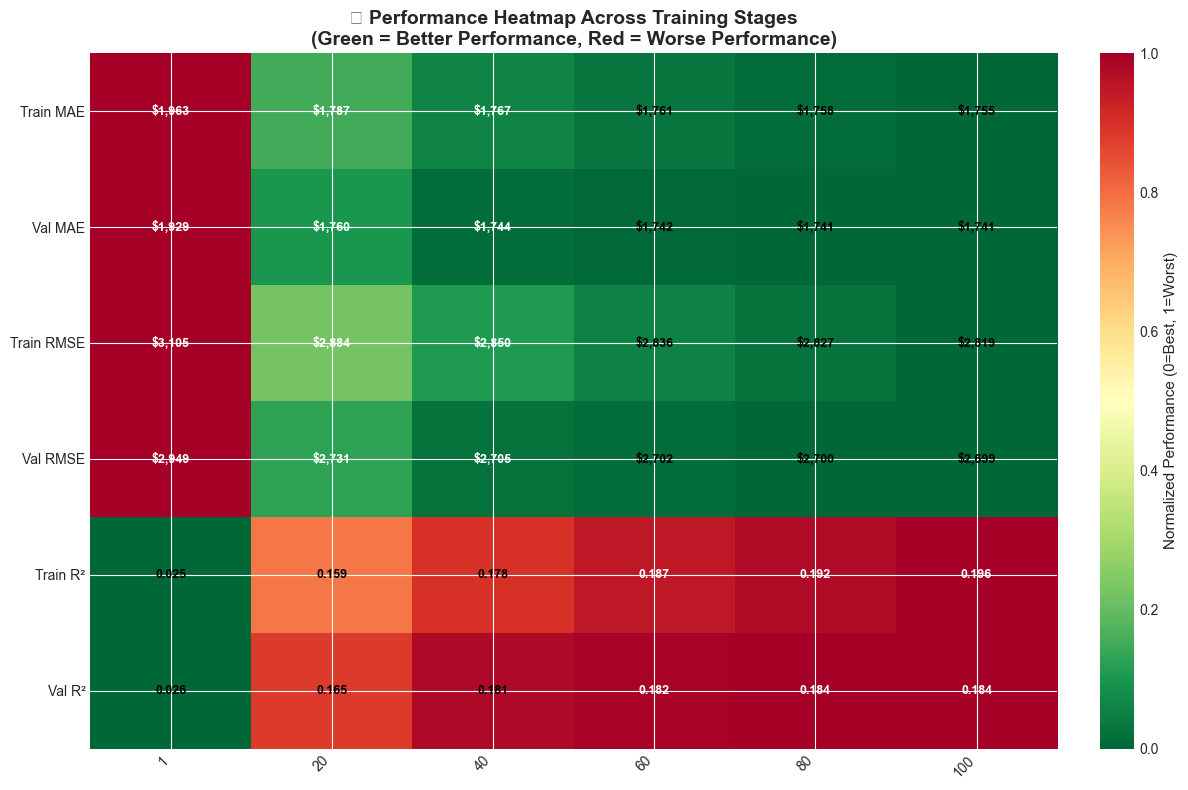

In [18]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA
df = pd.read_csv("medical_insurance.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# 3. BASIC DATA ANALYSIS
print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes.value_counts())

# 4. PREPROCESSING - HANDLE MISSING VALUES
print("\nnote: Outcome from previous commit gave missing values in dataset analysis. Handling missing values in the next step before encoding categorical features.")

# Check alcohol_freq values before fixing
print("\nAlcohol frequency before handling:")
print(df['alcohol_freq'].value_counts(dropna=False))

# Fill NaN with 'Unknown' as a valid category
df['alcohol_freq'] = df['alcohol_freq'].fillna('Unknown')

print("\nAlcohol frequency after handling:")
print(df['alcohol_freq'].value_counts())

# Verify no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

# 5. DROP UNNECESSARY FEATURES
columns_to_drop = [
    "person_id",
    "policy_term_years",
    "policy_changes_last_2yrs",
    "provider_quality",
    "risk_score",
    "annual_premium",
    "monthly_premium",
    "claims_count",
    "avg_claim_amount",
    "total_claims_paid"
]

df = df.drop(columns=columns_to_drop)

print("\nRemaining Features:", df.shape[1])

# 6. ENCODING CATEGORICAL DATA
categorical_cols = df.select_dtypes(include=["object"]).columns
print(f"\nCategorical columns to encode: {categorical_cols.tolist()}")

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# 7. DEFINE FEATURES & TARGET
X = df.drop("annual_medical_cost", axis=1)
y = df["annual_medical_cost"]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 8. DATA SPLITTING (70 / 10 / 20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

print("\nData split completed.")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# 9. SETTING HYPERPARAMETERS
hyperparams = {
    'n_estimators': 100,      # Number of boosting stages
    'learning_rate': 0.1,     # Shrinks contribution of each tree
    'max_depth': 3,           # Maximum depth of individual trees
    'min_samples_split': 2,   # Minimum samples required to split node
    'min_samples_leaf': 1,    # Minimum samples required at leaf node
    'subsample': 1.0,         # Fraction of samples used for fitting trees
    'random_state': 42        # For reproducibility
}

# 10. MODEL TRAINING
print("\nModel training started!")

# Create lists to store training progress
train_scores = []
val_scores = []
n_estimators_list = []

# Train with incremental learning to track progress
print("Training trees incrementally...")

# Get base model
model = GradientBoostingRegressor(**hyperparams, warm_start=True)

# Train incrementally to track performance
n_estimators_list = []
train_mae_list = []
val_mae_list = []
train_rmse_list = []
val_rmse_list = []
train_r2_list = []
val_r2_list = []

print("Training trees incrementally...")

# Train incrementally to track performance
for i in range(1, hyperparams['n_estimators'] + 1):
    model.set_params(n_estimators=i)
    model.fit(X_train, y_train)
    
    # Record progress every 20 trees to avoid too much output
    if i % 20 == 0 or i == 1 or i == hyperparams['n_estimators']:
        # Training predictions and metrics
        train_pred = model.predict(X_train)
        train_mae = mean_absolute_error(y_train, train_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        train_r2 = r2_score(y_train, train_pred)
        
        # Validation predictions and metrics
        val_pred = model.predict(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        val_r2 = r2_score(y_val, val_pred)
        
        # Store metrics
        n_estimators_list.append(i)
        train_mae_list.append(train_mae)
        val_mae_list.append(val_mae)
        train_rmse_list.append(train_rmse)
        val_rmse_list.append(val_rmse)
        train_r2_list.append(train_r2)
        val_r2_list.append(val_r2)
        
        print(f"Trees: {i:4d}/{hyperparams['n_estimators']} | "
              f"Train MAE: ${train_mae:,.2f} | Val MAE: ${val_mae:,.2f} | "
              f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")

print("\nModel training completed!")

# 11. CREATE TRAINING PROGRESS VISUALIZATIONS 
print("\n" + "="*60)
print("GENERATING TRAINING VISUALIZATIONS")
print("="*60)

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (18, 12)
plt.rcParams['font.size'] = 10

# Create a comprehensive figure with 2x4 subplots for 8 visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
fig.suptitle(f'Gradient Boosting Regressor - Comprehensive Training Analysis\nVersion 1: Baseline Parameters', 
             fontsize=16, fontweight='bold', y=0.98)

# PLOT 1: MAE vs Number of Trees
ax1 = axes[0, 0]
ax1.plot(n_estimators_list, train_mae_list, 'b-', linewidth=2.5, label='Training MAE', marker='o', markersize=6)
ax1.plot(n_estimators_list, val_mae_list, 'r-', linewidth=2.5, label='Validation MAE', marker='s', markersize=6)
ax1.fill_between(n_estimators_list, train_mae_list, val_mae_list, alpha=0.2, color='purple')
ax1.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error ($)', fontsize=11, fontweight='bold')
ax1.set_title('📊 MAE vs Number of Trees', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# PLOT 2: R² Score vs Number of Trees
ax2 = axes[0, 1]
ax2.plot(n_estimators_list, train_r2_list, 'b-', linewidth=2.5, label='Training R²', marker='o', markersize=6)
ax2.plot(n_estimators_list, val_r2_list, 'r-', linewidth=2.5, label='Validation R²', marker='s', markersize=6)
ax2.fill_between(n_estimators_list, train_r2_list, val_r2_list, alpha=0.2, color='orange')
ax2.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax2.set_title('🎯 R² Score vs Number of Trees', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)
ax2.set_facecolor('#f8f9fa')

# PLOT 3: RMSE vs Number of Trees
ax3 = axes[0, 2]
ax3.plot(n_estimators_list, train_rmse_list, 'b-', linewidth=2.5, label='Training RMSE', marker='o', markersize=6)
ax3.plot(n_estimators_list, val_rmse_list, 'r-', linewidth=2.5, label='Validation RMSE', marker='s', markersize=6)
ax3.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Root Mean Squared Error ($)', fontsize=11, fontweight='bold')
ax3.set_title('📈 RMSE vs Number of Trees\n(Sensitive to Large Errors)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#f8f9fa')

# PLOT 4: Overfitting Gap Analysis (MAE Difference)
ax4 = axes[0, 3]
overfitting_gap = [t - v for t, v in zip(train_mae_list, val_mae_list)]
colors_gap = ['red' if gap > 0 else 'green' for gap in overfitting_gap]
bars = ax4.bar(n_estimators_list, overfitting_gap, color=colors_gap, alpha=0.7, edgecolor='black', linewidth=1)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax4.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Train MAE - Val MAE ($)', fontsize=11, fontweight='bold')
ax4.set_title('⚠️ Overfitting Gap Analysis\n(Red = Overfitting, Green = Underfitting)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_facecolor('#f8f9fa')

# PLOT 5: Relative Improvement from Baseline
ax5 = axes[1, 0]
train_improvement = [100 * (train_mae_list[0] - e) / train_mae_list[0] for e in train_mae_list]
val_improvement = [100 * (val_mae_list[0] - e) / val_mae_list[0] for e in val_mae_list]

ax5.plot(n_estimators_list, train_improvement, 'b-', linewidth=2.5, label='Training Improvement %', marker='o', markersize=6)
ax5.plot(n_estimators_list, val_improvement, 'r-', linewidth=2.5, label='Validation Improvement %', marker='s', markersize=6)
ax5.fill_between(n_estimators_list, train_improvement, val_improvement, alpha=0.2, color='teal')
ax5.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Improvement from Baseline (%)', fontsize=11, fontweight='bold')
ax5.set_title('📉 Relative Improvement vs Baseline\n(First Tree = 0%)', fontsize=12, fontweight='bold')
ax5.legend(loc='lower right', fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_facecolor('#f8f9fa')

# PLOT 6: Learning Rate (Improvement per Tree Addition)
ax6 = axes[1, 1]
val_improvement_rate = []
for i in range(1, len(val_mae_list)):
    rate = (val_mae_list[i-1] - val_mae_list[i]) / val_mae_list[i-1] * 100
    val_improvement_rate.append(rate)

n_estimators_rate = n_estimators_list[1:]

# Color gradient based on improvement rate
colors_rate = plt.cm.plasma(np.linspace(0, 1, len(val_improvement_rate)))
bars_rate = ax6.bar(range(len(n_estimators_rate)), val_improvement_rate, color=colors_rate, alpha=0.7, edgecolor='black')
ax6.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax6.set_xticks(range(len(n_estimators_rate)))
ax6.set_xticklabels(n_estimators_rate, rotation=45)
ax6.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Improvement Rate (%)', fontsize=11, fontweight='bold')
ax6.set_title('⚡ Learning Rate: Improvement per Tree Addition\n(Larger = Faster Learning)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_facecolor('#f8f9fa')

# PLOT 7: Optimal Tree Selection with Gradient Colors
ax7 = axes[1, 2]

# Find best validation R²
best_idx = val_r2_list.index(max(val_r2_list))
best_trees = n_estimators_list[best_idx]
best_r2 = val_r2_list[best_idx]

# Create gradient color line
colors_line = plt.cm.RdYlGn(np.linspace(0, 1, len(n_estimators_list)))

for i in range(len(n_estimators_list) - 1):
    ax7.plot(n_estimators_list[i:i+2], val_r2_list[i:i+2], 
            color=colors_line[i], linewidth=3, marker='o', markersize=6)

# Highlight best point
ax7.scatter(best_trees, best_r2, color='gold', s=300, edgecolor='black', 
           zorder=5, linewidth=2, label=f'Optimal: {best_trees} trees\nR² = {best_r2:.4f}')

ax7.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax7.set_ylabel('Validation R² Score', fontsize=11, fontweight='bold')
ax7.set_title(f'🎯 Optimal Tree Selection\nBest at {best_trees} Trees (R² = {best_r2:.4f})', 
             fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)
ax7.legend(loc='lower right', fontsize=10)
ax7.set_facecolor('#f8f9fa')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=min(val_r2_list), vmax=max(val_r2_list)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax7, fraction=0.046, pad=0.04)
cbar.set_label('R² Score', fontsize=10)

# PLOT 8: Performance Summary Dashboard
ax8 = axes[1, 3]

# Create summary metrics
final_train_mae = train_mae_list[-1]
final_val_mae = val_mae_list[-1]
final_train_r2 = train_r2_list[-1]
final_val_r2 = val_r2_list[-1]

# Create bar chart for final performance
metrics = ['Train MAE', 'Val MAE', 'Train R²', 'Val R²']
values = [final_train_mae, final_val_mae, final_train_r2, final_val_r2]
colors_metrics = ['steelblue', 'coral', 'steelblue', 'coral']

bars_metrics = ax8.bar(metrics, values, color=colors_metrics, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars_metrics, values):
    if val < 1:  # For R² scores
        ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:  # For MAE values
        ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax8.set_ylabel('Value', fontsize=11, fontweight='bold')
ax8.set_title('📊 Final Model Performance Summary', fontsize=12, fontweight='bold')
ax8.set_facecolor('#f8f9fa')
ax8.grid(True, alpha=0.3, axis='y')

# Add a text box with optimal tree information
textstr = f'Optimal Trees: {best_trees}\nBest Val R²: {best_r2:.4f}\nFinal Val R²: {final_val_r2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax8.text(0.95, 0.05, textstr, transform=ax8.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('gradient_boosting_comprehensive_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("TRAINING SUMMARY STATISTICS")
print("="*60)

print(f"\n📈 Optimal Number of Trees: {best_trees}")
print(f"   Best Validation R² Score: {best_r2:.4f}")
print(f"   Best Validation MAE: ${val_mae_list[best_idx]:,.2f}")

print(f"\n🏁 Final Model Performance ({hyperparams['n_estimators']} trees):")
print(f"   Training MAE: ${train_mae_list[-1]:,.2f}")
print(f"   Validation MAE: ${val_mae_list[-1]:,.2f}")
print(f"   Training R²: {train_r2_list[-1]:.4f}")
print(f"   Validation R²: {val_r2_list[-1]:.4f}")

print(f"\n⚠️ Overfitting Assessment:")
gap_final = train_mae_list[-1] - val_mae_list[-1]
if gap_final > 100:
    print(f"   Gap: ${gap_final:,.2f} - ⚠️ Potential overfitting detected")
elif gap_final < -100:
    print(f"   Gap: ${gap_final:,.2f} - 📉 Model may be underfitting")
else:
    print(f"   Gap: ${gap_final:,.2f} - ✅ Good generalization")

print(f"\n📊 Learning Progress:")
print(f"   MAE Reduction: ${train_mae_list[0] - train_mae_list[-1]:,.2f} (Training)")
print(f"   MAE Reduction: ${val_mae_list[0] - val_mae_list[-1]:,.2f} (Validation)")
print(f"   R² Improvement: {train_r2_list[-1] - train_r2_list[0]:.4f} (Training)")
print(f"   R² Improvement: {val_r2_list[-1] - val_r2_list[0]:.4f} (Validation)")

# Create a performance heatmap to visualize all metrics across training stages
print("\n" + "="*60)
print("GENERATING PERFORMANCE HEATMAP")
print("="*60)

fig2, ax_heat = plt.subplots(1, 1, figsize=(12, 8))

# Create performance matrix for heatmap
performance_data = {
    'Trees': n_estimators_list,
    'Train MAE': train_mae_list,
    'Val MAE': val_mae_list,
    'Train RMSE': train_rmse_list,
    'Val RMSE': val_rmse_list,
    'Train R²': train_r2_list,
    'Val R²': val_r2_list
}

df_performance = pd.DataFrame(performance_data)

# Create normalized heatmap data
heatmap_data = df_performance.set_index('Trees').T
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(scaler.fit_transform(heatmap_data.T).T, 
                                   index=heatmap_data.index, 
                                   columns=heatmap_data.columns)

im = ax_heat.imshow(heatmap_normalized, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
ax_heat.set_xticks(range(len(heatmap_normalized.columns)))
ax_heat.set_xticklabels(heatmap_normalized.columns, rotation=45, ha='right')
ax_heat.set_yticks(range(len(heatmap_normalized.index)))
ax_heat.set_yticklabels(heatmap_normalized.index)
ax_heat.set_title('🔥 Performance Heatmap Across Training Stages\n(Green = Better Performance, Red = Worse Performance)', 
             fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label('Normalized Performance (0=Best, 1=Worst)', fontsize=11)

# Add text annotations with actual values
for i in range(len(heatmap_normalized.index)):
    for j in range(len(heatmap_normalized.columns)):
        value = heatmap_data.iloc[i, j]
        if 'MAE' in heatmap_normalized.index[i] or 'RMSE' in heatmap_normalized.index[i]:
            text = f'${value:,.0f}'
        else:
            text = f'{value:.3f}'
        ax_heat.text(j, i, text, ha="center", va="center", 
                    color="black" if value < heatmap_data.iloc[i].median() else "white",
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()